#DATA WRANGLING & EXPLORATORY DATA ANALYSIS (EDA)
**Dự án:** FitBit Fitness Tracker Data Analysis  
**Mục tiêu:** Làm sạch, tích hợp, khám phá dữ liệu và trích xuất đặc trưng (Feature Engineering) tạo tiền đề cho các mô hình Phân loại, Phân cụm, Phân tích luật kết hợp, Hồi quy (Classification, Clustering, Associate, Regression).

## Mục lục (Table of Contents)
1. [Khởi tạo môi trường & Cấu hình đường dẫn](#b0)
2. [Tải và Làm sạch dữ liệu gốc](#b1)
3. [Tích hợp dữ liệu (Merge Data) với tư duy Domain Knowledge](#b2)
4. [Khám phá Dữ liệu (EDA) & Phân tích Tương quan](#b3)
5. [Trích xuất Đặc trưng (Feature Engineering) & Xuất dữ liệu](#b4)

<a id="b0"></a>
## Khởi tạo môi trường & Cấu hình đường dẫn

Trước khi xử lý dữ liệu, chúng ta cần nạp các công cụ cần thiết và thiết lập không gian làm việc.
*   **Pandas & Numpy:** Thao tác dữ liệu cốt lõi.
*   **Seaborn & Matplotlib:** Trực quan hóa dữ liệu.
*   **Missingno:** Công cụ đắc lực để quan sát sự thiếu hụt dữ liệu một cách trực quan.
*   **Google Colab Drive:** Mount ổ đĩa để đọc/ghi file trực tiếp mà không sợ mất dữ liệu khi đóng phiên làm việc.

In [10]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Định nghĩa các đường dẫn (Path) tương ứng với cấu trúc thư mục
BASE_DIR = "/content/drive/MyDrive/Fitbit_Health_Analysis/"
RAW_DIR = os.path.join(BASE_DIR, "data/Fitabase Data 4.12.16-5.12.16/")
PROCESSED_V1_DIR = os.path.join(BASE_DIR, "data/processed/v1_baseline/")
FIG_DIR = os.path.join(BASE_DIR, "reports/figures/")

# 3. Đảm bảo thư mục lưu trữ tồn tại
os.makedirs(PROCESSED_V1_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Môi trường đã sẵn sàng!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Môi trường đã sẵn sàng!


<a id="b1"></a>
## Tải và Làm sạch dữ liệu gốc

**Tư duy xử lý (Chain-of-Thought):**
1.  **Dữ liệu thiết bị đeo (Wearable Data) rất dễ bị lặp:** Lỗi đồng bộ (sync) giữa đồng hồ và điện thoại thường sinh ra các dòng dữ liệu trùng lặp hoàn toàn. Cần sử dụng `drop_duplicates()`.
2.  **Chuẩn hóa cấu trúc cột:** Để tránh các lỗi "Case-sensitive" (phân biệt hoa/thường) khó chịu trong quá trình gọi tên biến sau này, ta chuyển toàn bộ tên cột về chữ in thường.
3.  **Đồng bộ hạt nhân thời gian (Time-grain):** Bảng `dailyActivity` và `sleepDay` có định dạng Datetime khác nhau (một bên có giờ, một bên không). Cần extract chính xác phần `Date` (Ngày) để làm khóa (Key) chuẩn bị cho việc ghép bảng.

In [13]:
def load_and_clean(path):
    """Hàm tải dữ liệu, xóa trùng lặp và chuẩn hóa tên cột."""
    df = pd.read_csv(path)
    df = df.drop_duplicates()
    df.columns = [col.lower() for col in df.columns]
    return df

# Load dữ liệu
daily_activity = load_and_clean(os.path.join(RAW_DIR, 'dailyActivity_merged.csv'))
sleep_day = load_and_clean(os.path.join(RAW_DIR, 'sleepDay_merged.csv'))

# Đồng bộ định dạng DateTime và trích xuất đúng phần 'Date' để Merge
daily_activity['date'] = pd.to_datetime(daily_activity['activitydate']).dt.date
sleep_day['date'] = pd.to_datetime(sleep_day['sleepday']).dt.date

# Loại bỏ cột ngày tháng gốc để tránh rác dữ liệu
daily_activity.drop(columns=['activitydate'], inplace=True)
sleep_day.drop(columns=['sleepday'], inplace=True)

print(f"Kích thước Daily Activity: {daily_activity.shape}")
print(f"Kích thước Sleep Day: {sleep_day.shape}")

display("--- 5 dòng đầu của Activity ---", df_activity.head(5))
display("--- 5 dòng đầu của Sleep ---", df_sleep.head(5))

Kích thước Daily Activity: (940, 15)
Kích thước Sleep Day: (410, 5)


'--- 5 dòng đầu của Activity ---'

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


'--- 5 dòng đầu của Sleep ---'

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


> **Phân tích nhanh:** Kích thước bảng `dailyActivity` lớn hơn gấp đôi so với `sleepDay`. Điều này phản ánh hành vi thực tế: người dùng tháo đồng hồ ra khi đi ngủ (để sạc hoặc do không thoải mái).



<a id="b2"></a>
## Tích hợp dữ liệu (Merge Data) với tư duy Domain Knowledge

Nếu dùng `Inner Join`, ta sẽ vĩnh viễn mất đi hơn 50% dữ liệu vận động hằng ngày của người dùng chỉ vì họ... không đeo đồng hồ đi ngủ.
*   **Chiến lược:** Sử dụng `Left Join` lấy `dailyActivity` làm gốc.
*   **Xử lý hậu Join:** Các giá trị NaN sinh ra ở dữ liệu giấc ngủ sẽ được điền bằng `0` (mang ý nghĩa thực tế là "Không ghi nhận dữ liệu giấc ngủ").

In [14]:
# Dùng left join để không làm mất dữ liệu những ngày không đeo đồng hồ khi ngủ
df_merged = pd.merge(daily_activity, sleep_day, on=['id', 'date'], how='left')

# Điền 0 cho các giá trị NaN sinh ra từ việc thiếu dữ liệu giấc ngủ
df_merged['totalsleeprecords'] = df_merged['totalsleeprecords'].fillna(0)
df_merged['totalminutesasleep'] = df_merged['totalminutesasleep'].fillna(0)
df_merged['totaltimeinbed'] = df_merged['totaltimeinbed'].fillna(0)

print(f"Kích thước tập dữ liệu sau khi gộp: {df_merged.shape}")
print(f"Kiểm tra Missing Values tổng thể:\n{df_merged.isnull().sum().max()} (Nếu là 0 tức là dữ liệu đã toàn vẹn)")

Kích thước tập dữ liệu sau khi gộp: (940, 18)
Kiểm tra Missing Values tổng thể:
0 (Nếu là 0 tức là dữ liệu đã toàn vẹn)


<a id="b3"></a>
## Khám phá Dữ liệu (EDA) & Phân tích Tương quan

Trước khi mô hình hóa, cần hiểu rõ mối quan hệ giữa các biến số.
*   **Tại sao lại là Spearman?** Các biến như số bước chân (`totalsteps`), phút vận động mạnh (`veryactiveminutes`) thường có phân phối lệch phải (right-skewed), không tuân theo quy luật chuẩn (Normal Distribution). Hệ số tương quan Spearman đánh giá dựa trên "thứ hạng" (rank) sẽ phản ánh chính xác hơn Pearson trong trường hợp này.
*   **Outliers (Dị thường):** Áp dụng phương pháp khoảng tứ phân vị (IQR) để phát hiện những ngày người dùng hoạt động một cách "bất thường" (ví dụ: chạy marathon).

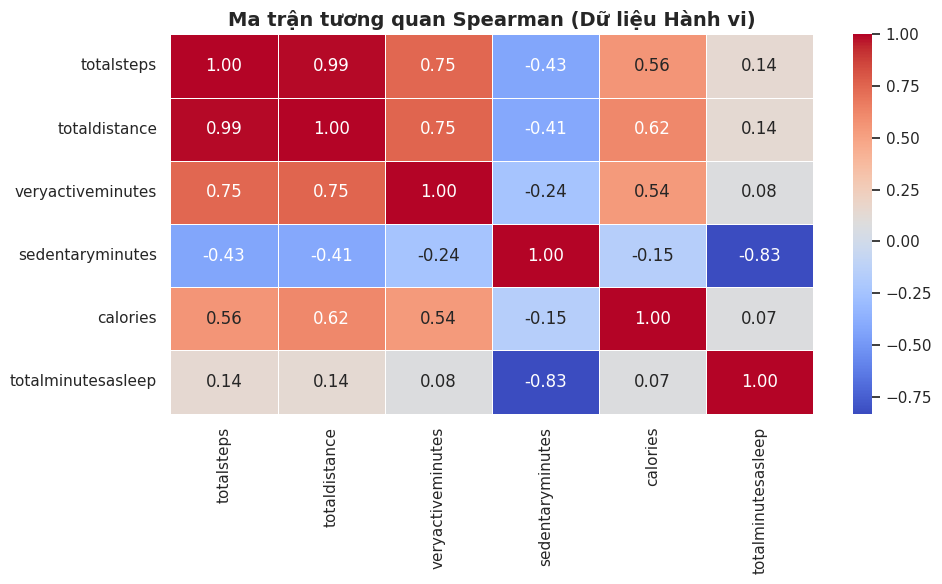

Số lượng Outliers phát hiện trong 'totalsteps': 12 dòng


In [16]:
# Phân tích tương quan (Spearman)
features_to_corr = ['totalsteps', 'totaldistance', 'veryactiveminutes',
                    'sedentaryminutes', 'calories', 'totalminutesasleep']

plt.figure(figsize=(10, 6))
correlation_matrix = df_merged[features_to_corr].corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Ma trận tương quan Spearman (Dữ liệu Hành vi)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_spearman_corr.png'))
plt.show()

# Phát hiện Outliers bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers_steps = detect_outliers_iqr(df_merged, 'totalsteps')
print(f"Số lượng Outliers phát hiện trong 'totalsteps': {len(outliers_steps)} dòng")

<a id="insights"></a>
### Phân tích Insights từ Ma trận Tương quan

Sau khi trực quan hóa ma trận tương quan Spearman và phát hiện Outliers, rút ra được 4 nhận định chiến lược quan trọng để định hướng cho các bước mô hình hóa tiếp theo:

 1. Nhóm tương quan "Đa cộng tuyến" (Cần thận trọng)
* **Chỉ số:** `totalsteps` và `totaldistance` có tương quan dương gần như tuyệt đối (**0.99**).
* **Phân tích nghiệp vụ:** Điều này là hiển nhiên vì FitBit (hay bất kỳ smartwatch nào) đều ước tính quãng đường (Distance) dựa trên số bước chân (Steps) nhân với chiều dài sải chân của người dùng.
* **Hành động cho luồng sau:** Trong các bài toán Hồi quy tuyến tính (Linear/Ridge Regression) ở **File 5**, việc giữ cả hai biến này sẽ gây ra hiện tượng **Đa cộng tuyến (Multicollinearity)**, làm nhiễu trọng số của mô hình. Tới lúc đó, chúng ta sẽ quyết định chỉ giữ lại `totalsteps` và drop (loại bỏ) `totaldistance`.

2. Yếu tố quyết định lượng Calo tiêu thụ
* **Chỉ số:** `calories` có tương quan dương ở mức khá với `totaldistance` (**0.62**) và `totalsteps` (**0.56**).
* **Phân tích nghiệp vụ:** Dữ liệu xác nhận đúng quy luật vật lý cơ bản: Vận động càng nhiều thì đốt càng nhiều Calo.
* **Góc nhìn sâu hơn:** Tuy nhiên, hệ số 0.56 - 0.62 chỉ ở mức trung bình - khá, không phải tương quan cực mạnh (ví dụ > 0.8). Tại sao? Vì lượng Calo tiêu thụ hằng ngày (Total Calories Burned) bị chi phối rất lớn bởi **BMR (Basal Metabolic Rate** - năng lượng tiêu hao lúc nghỉ ngơi để duy trì sự sống). BMR lại phụ thuộc vào Tuổi, Giới tính, Cân nặng, Chiều cao – những biến mà bộ dữ liệu hiện tại đang thiếu. Do đó, mô hình dự đoán Calories ở File 5 sẽ gặp chút thách thức.

3. Khám phá bất ngờ nhất: "Bẫy" thời gian 24h
* **Chỉ số:** `sedentaryminutes` (Phút ngồi tĩnh tại) và `totalminutesasleep` (Phút ngủ) có tương quan âm cực mạnh (**-0.83**).
* **Phân tích nghiệp vụ:** Khi nhìn thoáng qua, ta dễ nhầm lẫn rằng "Càng ngồi nhiều thì ngủ càng ít". Nhưng thực chất, đây là đặc tính của **Dữ liệu cấu thành (Compositional Data)**.
    * Mỗi ngày chỉ có một hằng số cố định là 1440 phút (24 giờ).
    * Thời gian Ngủ (thường 400-500 phút) và Thời gian Ngồi/Tĩnh tại (thường 700-1000 phút) là hai khối thời gian chiếm tỷ trọng lớn nhất.
    * Về mặt toán học, khi quỹ thời gian cho việc ngủ tăng lên, quỹ thời gian còn lại trong ngày tự động hẹp đi, buộc thời gian ngồi tĩnh tại phải giảm xuống. Đây là một Insight quan trọng để hiểu bản chất cấu trúc dữ liệu thời gian.

4. Nhận định về Outliers (Dữ liệu dị thường)
* **Kết quả:** Hệ thống phát hiện 12 ngày có `totalsteps` vượt ranh giới IQR (chiếm khoảng 3% tổng dữ liệu).
* **Phân tích nghiệp vụ:** Khác với các lỗi nhập liệu (như tuổi = 200) cần phải xóa bỏ, 12 dòng này đại diện cho những **"Ngày siêu vận động"** (ví dụ: người dùng đi leo núi, tham gia giải chạy marathon cuối tuần).
* **Hành động:** Chúng ta **tuyệt đối không xóa** các dòng này trong bài toán Phân loại (Classification - File 4), vì đây chính là các mẫu dữ liệu quý giá (tín hiệu mạnh) để mô hình học cách nhận diện chính xác nhãn "Active Day" (Ngày năng động).

<a id="b4"></a>
## Trích xuất Đặc trưng (Feature Engineering) & Xuất dữ liệu


1.  **Dữ liệu Master (`master_daily_v1.csv`):** Thêm các đặc trưng số học và thời gian để phục vụ thuật toán Clustering (Phân cụm) và Classification/Regression sau này.
2.  **Dữ liệu Giao dịch (`transaction_v1.csv`):** Chuyển đổi dữ liệu liên tục thành dạng phân khúc (Binning) như `High_Burn`, `Poor_Sleep`, `Weekend`, sau đó dùng **One-Hot Encoding** (Biến đổi thành True/False). Dạng ma trận thưa (Sparse Matrix) này là điều kiện bắt buộc để thuật toán FP-Growth khai phá luật

In [17]:
# Thuộc tính Thời gian (Time Features)
df_merged['date'] = pd.to_datetime(df_merged['date']) # Convert lại sang datetime để extract ngày
df_merged['day_of_week'] = df_merged['date'].dt.day_name()
# Chuyển thành chuỗi để làm luật kết hợp ở File 2 trực quan hơn (Weekend / Weekday)
df_merged['day_type'] = np.where(df_merged['date'].dt.dayofweek.isin([5, 6]), 'Weekend', 'Weekday')

# Hiệu suất giấc ngủ (Sleep Efficiency %)
df_merged['sleep_efficiency'] = np.where(
    df_merged['totaltimeinbed'] > 0,
    (df_merged['totalminutesasleep'] / df_merged['totaltimeinbed']) * 100,
    0
)

# Phân nhóm Lifestyle (Binning theo chuẩn Y khoa Public Health)
bins_steps = [-1, 5000, 7500, 10000, np.inf]
labels_steps = ['Sedentary_Lifestyle', 'Low_Active', 'Somewhat_Active', 'Highly_Active']
df_merged['lifestyle_group'] = pd.cut(df_merged['totalsteps'], bins=bins_steps, labels=labels_steps)

# Phân nhóm Giấc ngủ (Sleep Binning)
def categorize_sleep(minutes):
    if minutes == 0: return 'No_Sleep_Data'
    elif minutes < 360: return 'Poor_Sleep'
    elif minutes <= 480: return 'Normal_Sleep'
    else: return 'Over_Sleep'
df_merged['sleep_group'] = df_merged['totalminutesasleep'].apply(categorize_sleep)

# Phân nhóm Calorie
df_merged['calorie_group'] = pd.qcut(df_merged['calories'], q=3, labels=['Low_Burn', 'Medium_Burn', 'High_Burn'])


# CHUẨN BỊ BỘ DỮ LIỆU GIAO DỊCH (TRANSACTIONAL)

# Gộp các thuộc tính phân loại (Categorical)
transaction_cols = ['lifestyle_group', 'sleep_group', 'calorie_group', 'day_type']
transaction_df = df_merged[transaction_cols].copy()

# One-hot Encoding để tương thích hoàn toàn với thuật toán Apriori / FP-Growth
transaction_encoded = pd.get_dummies(transaction_df).astype(bool)



In [18]:
# XUẤT FILE LƯU LÊN GOOGLE DRIVE

master_path = os.path.join(PROCESSED_V1_DIR, 'master_daily_v1.csv')
transaction_path = os.path.join(PROCESSED_V1_DIR, 'transaction_v1.csv')

df_merged.to_csv(master_path, index=False)
transaction_encoded.to_csv(transaction_path, index=False)

print("HOÀN TẤT PIPELINE FILE 1!")
print(f"[Output 1] Master Dataset (Clustering/Model): {master_path}")
print(f"[Output 2] Transaction Dataset (Association Rules): {transaction_path}")

HOÀN TẤT PIPELINE FILE 1!
[Output 1] Master Dataset (Clustering/Model): /content/drive/MyDrive/Fitbit_Health_Analysis/data/processed/v1_baseline/master_daily_v1.csv
[Output 2] Transaction Dataset (Association Rules): /content/drive/MyDrive/Fitbit_Health_Analysis/data/processed/v1_baseline/transaction_v1.csv
